# Head vs Travel Comparison (All-Spike, 99% Tuning)

This notebook compares `head_all_spike` vs `travel_all_spike` using the 99% tuning threshold (`pass_99`).

It creates one 2x2 figure with:
1. Tuned-cell counts by category (CS+, CS-, nonPLC)
2. Pooled tuned-cell counts (Head vs Travel)
3. Tuned-cell MRL comparison by category
4. Pooled tuned-cell MRL comparison

Statistics shown on plots:
- Fisher exact test for tuned-count comparisons
- Mann-Whitney U test for tuned-cell MRL comparisons


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, mannwhitneyu
from IPython.display import display


In [2]:
BASE_DIR = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4')
ROOT = BASE_DIR / 'data' / 'egocentric_tuning_carpenter'
HEAD_RUN = ROOT / 'head_all_spike'
TRAVEL_RUN = ROOT / 'travel_all_spike'
HEAD_CSV = HEAD_RUN / 'egocentric_tuning_summary.csv'
TRAVEL_CSV = TRAVEL_RUN / 'egocentric_tuning_summary.csv'
OUT_DIR = ROOT / 'comparison_head_vs_travel_all_spike'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG = OUT_DIR / 'head_vs_travel_all_spike_99pct_comparison_2x2.svg'

for p in [HEAD_CSV, TRAVEL_CSV]:
    if not p.exists():
        raise FileNotFoundError(f'Missing summary CSV: {p}')

head = pd.read_csv(HEAD_CSV)
travel = pd.read_csv(TRAVEL_CSV)

def to_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin(['true', '1', 'yes'])

for df, mode in [(head, 'head'), (travel, 'travel')]:
    df['mode'] = mode
    df['cell_key'] = df['category'].astype(str) + '|' + df['animal_id'].astype(str) + '|' + df['cell_idx'].astype(str)
    df['pass_99_bool'] = to_bool(df['pass_99'])
    df['real_mrl'] = pd.to_numeric(df['real_mrl'], errors='coerce')

cat_order = ['CSplus', 'CSminus', 'all-nonPLC']
cat_label = {'CSplus': 'CS+', 'CSminus': 'CS-', 'all-nonPLC': 'nonPLC'}

print('Head rows:', len(head))
print('Travel rows:', len(travel))


Head rows: 46
Travel rows: 47


In [3]:
# Statistical summaries
count_stats = []
for cat in cat_order:
    h = head[head['category'] == cat]
    t = travel[travel['category'] == cat]

    h_tuned = int(h['pass_99_bool'].sum())
    h_total = int(len(h))
    t_tuned = int(t['pass_99_bool'].sum())
    t_total = int(len(t))

    table = np.array([[h_tuned, h_total - h_tuned], [t_tuned, t_total - t_tuned]], dtype=int)
    _, p = fisher_exact(table, alternative='two-sided')

    count_stats.append({
        'category': cat,
        'head_tuned': h_tuned,
        'head_total': h_total,
        'travel_tuned': t_tuned,
        'travel_total': t_total,
        'p_fisher': p,
    })

count_stats_df = pd.DataFrame(count_stats)

head_tuned_all = int(head['pass_99_bool'].sum())
head_total_all = int(len(head))
travel_tuned_all = int(travel['pass_99_bool'].sum())
travel_total_all = int(len(travel))
table_all = np.array([[head_tuned_all, head_total_all - head_tuned_all], [travel_tuned_all, travel_total_all - travel_tuned_all]], dtype=int)
_, p_counts_all = fisher_exact(table_all, alternative='two-sided')

mrl_stats = []
for cat in cat_order:
    h_vals = head[(head['category'] == cat) & (head['pass_99_bool'])]['real_mrl'].dropna().to_numpy()
    t_vals = travel[(travel['category'] == cat) & (travel['pass_99_bool'])]['real_mrl'].dropna().to_numpy()
    if len(h_vals) > 0 and len(t_vals) > 0:
        u, p = mannwhitneyu(h_vals, t_vals, alternative='two-sided')
    else:
        u, p = np.nan, np.nan
    mrl_stats.append({
        'category': cat,
        'head_n': len(h_vals),
        'travel_n': len(t_vals),
        'head_median': float(np.nanmedian(h_vals)) if len(h_vals) else np.nan,
        'travel_median': float(np.nanmedian(t_vals)) if len(t_vals) else np.nan,
        'u_stat': u,
        'p_mwu': p,
    })

mrl_stats_df = pd.DataFrame(mrl_stats)

head_tuned_mrl_all = head[head['pass_99_bool']]['real_mrl'].dropna().to_numpy()
travel_tuned_mrl_all = travel[travel['pass_99_bool']]['real_mrl'].dropna().to_numpy()
if len(head_tuned_mrl_all) > 0 and len(travel_tuned_mrl_all) > 0:
    u_all, p_mrl_all = mannwhitneyu(head_tuned_mrl_all, travel_tuned_mrl_all, alternative='two-sided')
else:
    u_all, p_mrl_all = np.nan, np.nan

display(count_stats_df)
display(mrl_stats_df)
print(f'Pooled tuned-count Fisher p = {p_counts_all:.4g}')
print(f'Pooled tuned-MRL Mann-Whitney p = {p_mrl_all:.4g}')


,category,head_tuned,head_total,travel_tuned,travel_total,p_fisher
0,CSplus,5,12,4,12,1.0
1,CSminus,0,8,0,8,1.0
2,all-nonPLC,7,26,8,27,1.0


,category,head_n,travel_n,head_median,travel_median,u_stat,p_mwu
0,CSplus,5,4,0.450492,0.280202,16.0,0.190476
1,CSminus,0,0,NaN,NaN,NaN,NaN
2,all-nonPLC,7,8,0.324264,0.294118,34.0,0.535820


Pooled tuned-count Fisher p = 1
Pooled tuned-MRL Mann-Whitney p = 0.1749


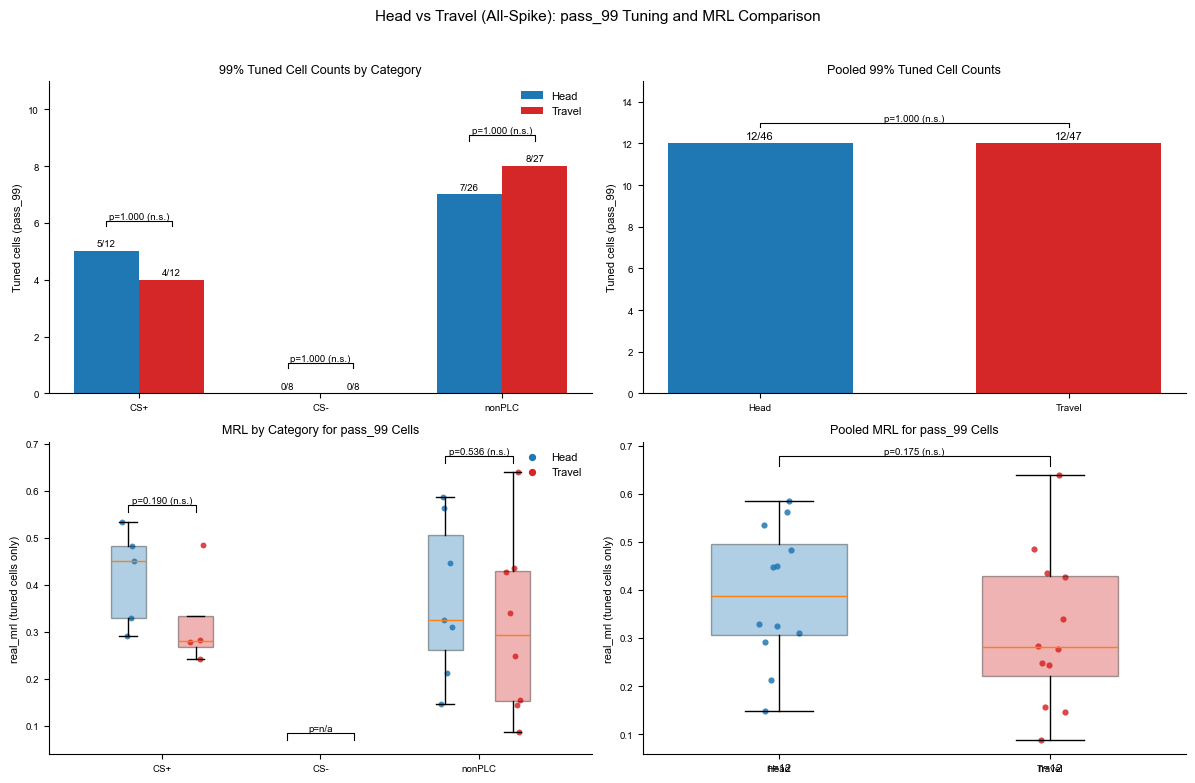

Saved figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/egocentric_tuning_carpenter/comparison_head_vs_travel_all_spike/head_vs_travel_all_spike_99pct_comparison_2x2.svg


In [4]:
# 2x2 figure with on-plot statistics
def p_text(p):
    if np.isnan(p):
        return 'p=n/a'
    if p < 0.001:
        return f'p={p:.2e} (***)'
    if p < 0.01:
        return f'p={p:.3f} (**)'
    if p < 0.05:
        return f'p={p:.3f} (*)'
    return f'p={p:.3f} (n.s.)'

def add_bracket(ax, x1, x2, y, text, h=0.15, lw=0.8):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='k', lw=lw, clip_on=False)
    ax.text((x1 + x2) / 2.0, y + h, text, ha='center', va='bottom', fontsize=7)

head_color = '#1f77b4'
travel_color = '#d62728'

style = {
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
}

with plt.rc_context(style):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # (1) Tuned counts by category
    ax = axes[0, 0]
    x = np.arange(len(cat_order), dtype=float)
    w = 0.36
    head_vals = [int(count_stats_df.loc[count_stats_df['category'] == c, 'head_tuned'].iloc[0]) for c in cat_order]
    travel_vals = [int(count_stats_df.loc[count_stats_df['category'] == c, 'travel_tuned'].iloc[0]) for c in cat_order]
    head_totals = [int(count_stats_df.loc[count_stats_df['category'] == c, 'head_total'].iloc[0]) for c in cat_order]
    travel_totals = [int(count_stats_df.loc[count_stats_df['category'] == c, 'travel_total'].iloc[0]) for c in cat_order]

    bars_h = ax.bar(x - w / 2, head_vals, width=w, color=head_color, label='Head')
    bars_t = ax.bar(x + w / 2, travel_vals, width=w, color=travel_color, label='Travel')
    ax.set_xticks(x)
    ax.set_xticklabels([cat_label[c] for c in cat_order])
    ax.set_ylabel('Tuned cells (pass_99)')
    ax.set_title('99% Tuned Cell Counts by Category')
    ax.legend(frameon=False, loc='upper right')

    y_max = max(head_vals + travel_vals + [1])
    ax.set_ylim(0, y_max + 3.0)
    for i, (bh, bt) in enumerate(zip(bars_h, bars_t)):
        ax.text(bh.get_x() + bh.get_width() / 2, bh.get_height() + 0.1, f"{head_vals[i]}/{head_totals[i]}",
                ha='center', va='bottom', fontsize=7)
        ax.text(bt.get_x() + bt.get_width() / 2, bt.get_height() + 0.1, f"{travel_vals[i]}/{travel_totals[i]}",
                ha='center', va='bottom', fontsize=7)
        p = float(count_stats_df.loc[count_stats_df['category'] == cat_order[i], 'p_fisher'].iloc[0])
        y0 = max(head_vals[i], travel_vals[i]) + 0.9
        add_bracket(ax, x[i] - w / 2, x[i] + w / 2, y0, p_text(p), h=0.18)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # (2) Pooled tuned counts
    ax = axes[0, 1]
    pooled_x = np.array([0.0, 1.0])
    pooled_vals = [head_tuned_all, travel_tuned_all]
    pooled_totals = [head_total_all, travel_total_all]
    ax.bar(pooled_x, pooled_vals, color=[head_color, travel_color], width=0.6)
    ax.set_xticks(pooled_x)
    ax.set_xticklabels(['Head', 'Travel'])
    ax.set_ylabel('Tuned cells (pass_99)')
    ax.set_title('Pooled 99% Tuned Cell Counts')
    y_max = max(pooled_vals + [1])
    ax.set_ylim(0, y_max + 3.0)
    for i, v in enumerate(pooled_vals):
        ax.text(pooled_x[i], v + 0.12, f"{v}/{pooled_totals[i]}", ha='center', va='bottom', fontsize=8)
    add_bracket(ax, pooled_x[0], pooled_x[1], y_max + 0.8, p_text(p_counts_all), h=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # (3) Tuned-cell MRL by category
    ax = axes[1, 0]
    width = 0.32
    centers = np.arange(len(cat_order), dtype=float)
    rng = np.random.default_rng(42)

    for i, cat in enumerate(cat_order):
        h_vals = head[(head['category'] == cat) & (head['pass_99_bool'])]['real_mrl'].dropna().to_numpy()
        t_vals = travel[(travel['category'] == cat) & (travel['pass_99_bool'])]['real_mrl'].dropna().to_numpy()

        left = centers[i] - width / 1.5
        right = centers[i] + width / 1.5

        if len(h_vals) > 0:
            bp_h = ax.boxplot([h_vals], positions=[left], widths=0.22, patch_artist=True, showfliers=False)
            bp_h['boxes'][0].set_facecolor(head_color)
            bp_h['boxes'][0].set_alpha(0.35)
            jit = rng.uniform(-0.05, 0.05, len(h_vals))
            ax.scatter(np.full(len(h_vals), left) + jit, h_vals, s=18, color=head_color, alpha=0.85, linewidths=0)

        if len(t_vals) > 0:
            bp_t = ax.boxplot([t_vals], positions=[right], widths=0.22, patch_artist=True, showfliers=False)
            bp_t['boxes'][0].set_facecolor(travel_color)
            bp_t['boxes'][0].set_alpha(0.35)
            jit = rng.uniform(-0.05, 0.05, len(t_vals))
            ax.scatter(np.full(len(t_vals), right) + jit, t_vals, s=18, color=travel_color, alpha=0.85, linewidths=0)

        p = float(mrl_stats_df.loc[mrl_stats_df['category'] == cat, 'p_mwu'].iloc[0])
        ymax_cat = 0.05
        if len(h_vals):
            ymax_cat = max(ymax_cat, float(np.nanmax(h_vals)))
        if len(t_vals):
            ymax_cat = max(ymax_cat, float(np.nanmax(t_vals)))
        add_bracket(ax, left, right, ymax_cat + 0.02, p_text(p), h=0.015)

    ax.set_xticks(centers)
    ax.set_xticklabels([cat_label[c] for c in cat_order])
    ax.set_ylabel('real_mrl (tuned cells only)')
    ax.set_title('MRL by Category for pass_99 Cells')
    ax.scatter([], [], color=head_color, label='Head', s=18)
    ax.scatter([], [], color=travel_color, label='Travel', s=18)
    ax.legend(frameon=False, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # (4) Pooled tuned-cell MRL
    ax = axes[1, 1]
    pooled_mrl = [head_tuned_mrl_all, travel_tuned_mrl_all]
    bp = ax.boxplot(pooled_mrl, positions=[1, 2], widths=0.5, patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor(head_color)
    bp['boxes'][0].set_alpha(0.35)
    bp['boxes'][1].set_facecolor(travel_color)
    bp['boxes'][1].set_alpha(0.35)

    jit_h = rng.uniform(-0.08, 0.08, len(head_tuned_mrl_all)) if len(head_tuned_mrl_all) else np.array([])
    jit_t = rng.uniform(-0.08, 0.08, len(travel_tuned_mrl_all)) if len(travel_tuned_mrl_all) else np.array([])
    if len(head_tuned_mrl_all):
        ax.scatter(np.full(len(head_tuned_mrl_all), 1.0) + jit_h, head_tuned_mrl_all, s=20, color=head_color, alpha=0.85, linewidths=0)
    if len(travel_tuned_mrl_all):
        ax.scatter(np.full(len(travel_tuned_mrl_all), 2.0) + jit_t, travel_tuned_mrl_all, s=20, color=travel_color, alpha=0.85, linewidths=0)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Head', 'Travel'])
    ax.set_ylabel('real_mrl (tuned cells only)')
    ax.set_title('Pooled MRL for pass_99 Cells')

    ymax = 0.05
    if len(head_tuned_mrl_all):
        ymax = max(ymax, float(np.nanmax(head_tuned_mrl_all)))
    if len(travel_tuned_mrl_all):
        ymax = max(ymax, float(np.nanmax(travel_tuned_mrl_all)))
    add_bracket(ax, 1, 2, ymax + 0.02, p_text(p_mrl_all), h=0.02)

    ax.text(1, 0.02, f'n={len(head_tuned_mrl_all)}', ha='center', va='bottom', fontsize=8)
    ax.text(2, 0.02, f'n={len(travel_tuned_mrl_all)}', ha='center', va='bottom', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle('Head vs Travel (All-Spike): pass_99 Tuning and MRL Comparison', fontsize=11)
    fig.tight_layout(rect=[0, 0.01, 1, 0.96])
    fig.savefig(OUT_FIG, bbox_inches='tight')
    plt.show()

print(f'Saved figure: {OUT_FIG}')
